# Домашнее задание 3 - Проверка статистических гипотез и параметрические критерии

**ВАЖНО: Обязательно для каждой задачи строим график и показываем куда попадает наше значение, если в задаче нужно проверить статистическую гипотезу**
\
**При отсутствии графиков возможна полная потеря баллов за задание**

### Задача 1 (1 балл)

Пусть X1,X2,…,Xn​ — независимые и одинаково распределенные случайные величины из нормального распределения с неизвестным средним μ и известной дисперсией σ^2=25. Из выборки объема n=64 получено выборочное среднее =102.
\
Проверьте гипотезу H0:μ=100 против альтернативы H1:μ>100 на уровне значимости α=0.01.
\
Вычислите p-значение этого теста.

Z-статистика: 3.20
p-значение: 0.0007
Отклоняем нулевую гипотезу H0: μ = 100 в пользу H1: μ > 100


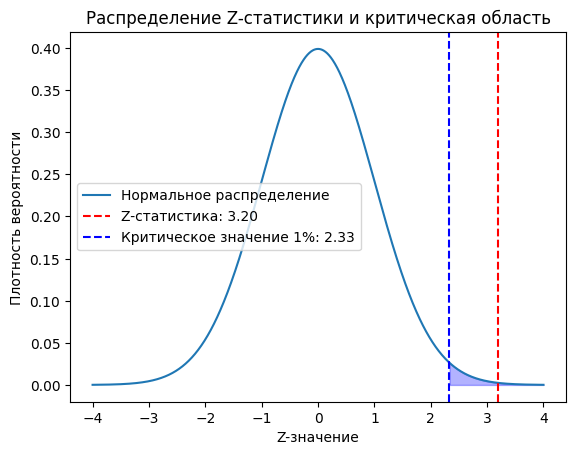

In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.stats import t
import matplotlib.pyplot as plt

std = np.sqrt(25)
n = 64
mean = 102
mean_0 = 100
alpha = 0.01

z = (mean - mean_0) / (std / np.sqrt(n))
p_value = 1 - norm.cdf(z)


print(f"Z-статистика: {z:.2f}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0: μ = 100 в пользу H1: μ > 100")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: μ = 100")

x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)
plt.plot(x, y, label="Нормальное распределение")
plt.axvline(z, color='red', linestyle='--', label=f"Z-статистика: {z:.2f}")
z_critical = norm.ppf(1 - alpha)
plt.axvline(z_critical, color='blue', linestyle='--', label=f"Критическое значение 1%: {z_critical:.2f}")
plt.fill_between(x, 0, y, where=(x >= z_critical), color="blue", alpha=0.3)

plt.legend()
plt.xlabel("Z-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение Z-статистики и критическая область")
plt.show()

### Задача 2 (1 балл)

Даны три независимые выборки. Первая выборка объемом 35 наблюдений имеет выборочное среднее 10.2 и выборочную дисперсию 2.5. Вторая выборка объемом 30 наблюдений имеет выборочное среднее 9.8 и выборочную дисперсию 2.8. Третья выборка объемом 40 наблюдений имеет выборочное среднее 10.5 и выборочную дисперсию 3.0.

Проверьте гипотезу о том, что средние всех трех выборок равны, на уровне значимости 0.05.
Оцените статистическую значимость результатов и постройте доверительные интервалы c графиками для каждого из средних.

**Использовать попарное сравнение для получения результата**

Выборки: (1) и (2): t-статистика = 0.99, p-value = 0.3283
Выборки: (1) и (3): t-статистика = -0.78, p-value = 0.4356
Выборки: (2) и (3): t-статистика = -1.71, p-value = 0.0929
Принимаем нулевую гипотезу H0: средние значения всех выборок равны
Доверительный интервал для Выборки 1: (9.66, 10.74)
Доверительный интервал для Выборки 2: (9.18, 10.42)
Доверительный интервал для Выборки 3: (9.95, 11.05)


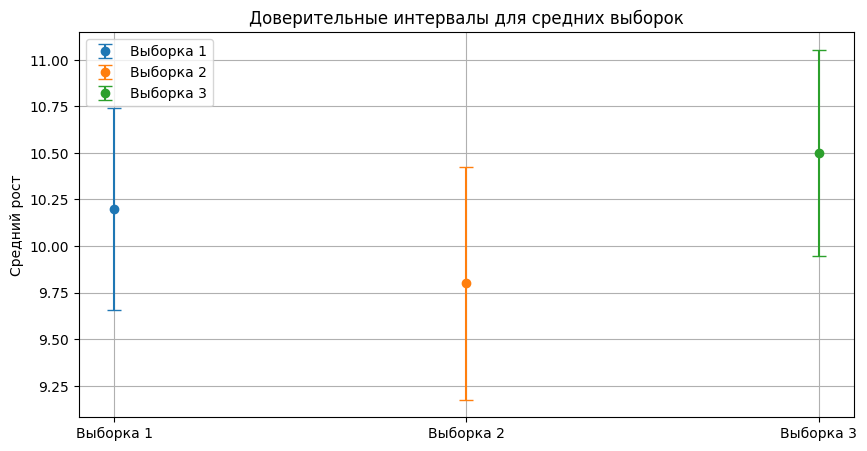

In [ ]:
n1 = 35
mean1 = 10.2
std1 = np.sqrt(2.5)

n2 = 30
mean2 = 9.8
std2 = np.sqrt(2.8)

n3 = 40
mean3 = 10.5
std3 = np.sqrt(3.0)

alpha = 0.05

"""
H0 : Средние значение всех выборок равны (=)
H1 : Средние значения всех выборок не равны (=/=)
"""

# Функция для t-теста двух выборок
def t_test_ind(mean1, std1, n1, mean2, std2, n2):
    t_stat = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))
    df = ((std1**2 / n1 + std2**2 / n2)**2) / (((std1**2 / n1)**2) / (n1 - 1) + ((std2**2 / n2)**2) / (n2 - 1))
    p_value = (1 - t.cdf(abs(t_stat), df)) * 2
    return t_stat, p_value

# Попарные t-тесты
t_stat_12, p_value_12 = t_test_ind(mean1, std1, n1, mean2, std2, n2)
t_stat_13, p_value_13 = t_test_ind(mean1, std1, n1, mean3, std3, n3)
t_stat_23, p_value_23 = t_test_ind(mean2, std2, n2, mean3, std3, n3)

print(f"Выборки: (1) и (2): t-статистика = {t_stat_12:.2f}, p-value = {p_value_12:.4f}")
print(f"Выборки: (1) и (3): t-статистика = {t_stat_13:.2f}, p-value = {p_value_13:.4f}")
print(f"Выборки: (2) и (3): t-статистика = {t_stat_23:.2f}, p-value = {p_value_23:.4f}")

if p_value_12 < alpha and p_value_13 < alpha and p_value_23 < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем H1: средние значения хотя бы двух выборок различаются")
else:
    print("Принимаем нулевую гипотезу H0: средние значения всех выборок равны")


conf_intervals = {}
for i, (mean, std, n) in enumerate([(mean1, std1, n1), (mean2, std2, n2), (mean3, std3, n3)], start=1):
    se = std / np.sqrt(n)
    ci_low = mean - t.ppf(1 - alpha / 2, n - 1) * se
    ci_high = mean + t.ppf(1 - alpha / 2, n - 1) * se
    conf_intervals[f"Выборка {i}"] = (ci_low, mean, ci_high)
    print(f"Доверительный интервал для Выборки {i}: ({ci_low:.2f}, {ci_high:.2f})")

# График доверительных интервалов
plt.figure(figsize=(10, 5))
for i, (label, (ci_low, mean, ci_high)) in enumerate(conf_intervals.items(), start=1):
    plt.errorbar(i, mean, yerr=[[mean - ci_low], [ci_high - mean]], fmt='o', label=label, capsize=5)

plt.xticks([1, 2, 3], ["Выборка 1", "Выборка 2", "Выборка 3"])
plt.ylabel("Средний рост")
plt.title("Доверительные интервалы для средних выборок")
plt.legend()
plt.grid()
plt.show()

### Задача 3 (1 балл)

Тестирование параметра распределения Пуассона

Выборка из 60 наблюдений была получена из распределения Пуассона с неизвестным параметром. Известно, что среднее количество наблюдений в выборке равно 4.8.

Проверьте гипотезу о том, что параметр распределения Пуассона равен 5 против альтернативы, что он меньше 5. Используйте уровень значимости 0.05.
Вычислите p-значение и сделайте вывод о гипотезе.

Z-статистика: -0.69
p-значение: 0.2442
Нет оснований отклонить нулевую гипотезу H0: λ = 5


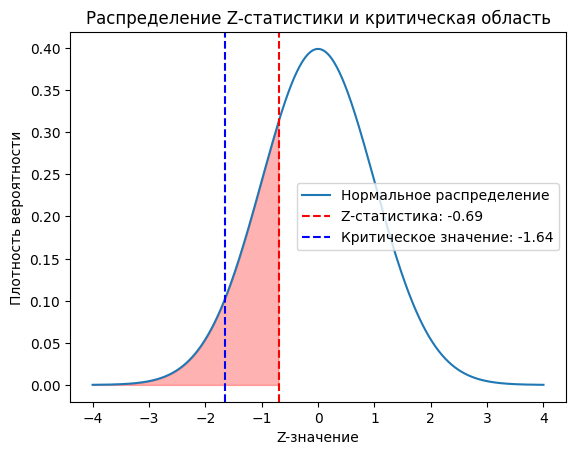

In [ ]:
"""
Исходя из ЦПТ, будем считать, что наша выборка достаточна, чтобы
утверждать, что распределение выборочного среднего любого распределения с
конечным средним и дисперсией будет приближаться к нормальному распределению.
Поэтому в задаче я буду использовать Нормальное распределение
"""

lambda_0 = 5
sample_mean = 4.8
n = 60
alpha = 0.05

z_stat = (sample_mean - lambda_0) / ((lambda_0 / n) ** 0.5)
p_value = norm.cdf(z_stat)

print(f"Z-статистика: {z_stat:.2f}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0: λ = 5 в пользу H1: λ < 5")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: λ = 5")


x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)
plt.plot(x, y, label="Нормальное распределение")
plt.axvline(z_stat, color='red', linestyle='--', label=f"Z-статистика: {z_stat:.2f}")
plt.fill_between(x, 0, y, where=(x <= z_stat), color="red", alpha=0.3)
z_critical = norm.ppf(alpha)
plt.axvline(z_critical, color='blue', linestyle='--', label=f"Критическое значение: {z_critical:.2f}")
plt.legend()
plt.xlabel("Z-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение Z-статистики и критическая область")
plt.show()

### Задача 4 (1 балл)

Компания заявляет, что среднее время работы их нового аккумулятора составляет 100 часов. Независимая лаборатория протестировала 25 случайно выбранных аккумуляторов и получила среднее время работы 95 часов при стандартном отклонении 10 часов. Можно ли на уровне значимости 1% утверждать, что реальное среднее время работы аккумуляторов меньше заявленного?

Z-статистика: -2.50
p-значение: 0.0062
Отклоняем нулевую гипотезу H0: среднее время работы составляет 100 часов, в пользу H1: время работы меньше 100 часов


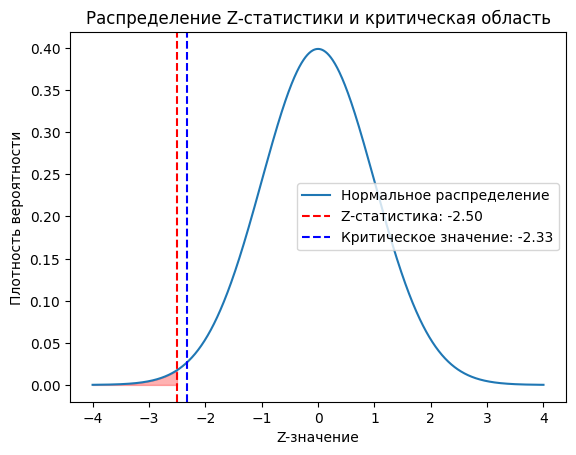

In [ ]:
mean_0 = 100
n = 25
mean_1 = 95
std = 10
alpha = 0.01

z = (mean_1 - mean_0) / (std / np.sqrt(n))
p_value = norm.cdf(z) # левосторонний тест

print(f"Z-статистика: {z:.2f}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0: среднее время работы составляет 100 часов, в пользу H1: время работы меньше 100 часов")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: среднее время работы составляет 100 часов")

x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)
plt.plot(x, y, label="Нормальное распределение")
plt.axvline(z, color='red', linestyle='--', label=f"Z-статистика: {z:.2f}")
plt.fill_between(x, 0, y, where=(x <= z), color="red", alpha=0.3)
z_critical = norm.ppf(alpha)
plt.axvline(z_critical, color='blue', linestyle='--', label=f"Критическое значение: {z_critical:.2f}")
plt.legend()
plt.xlabel("Z-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение Z-статистики и критическая область")
plt.show()

### Задача 5 (1 балл)

В ходе медицинского исследования сравнивается эффективность нового препарата для снижения артериального давления с существующим. Первой группе из 30 пациентов назначают новый препарат, и среднее снижение давления составляет 8 мм рт. ст. со стандартным отклонением 2 мм рт. ст. Второй группе из 30 пациентов дают существующий препарат, и среднее снижение составляет 6 мм рт. ст. со стандартным отклонением 3 мм рт. ст. Является ли новый препарат более эффективным на уровне значимости 5%?

t-статистика: 3.04
Число степеней свободы: 50.53
p-значение: 0.0019
Отклоняем нулевую гипотезу H0 и выбираем H1: новый препарат более эффективен, чем существующий


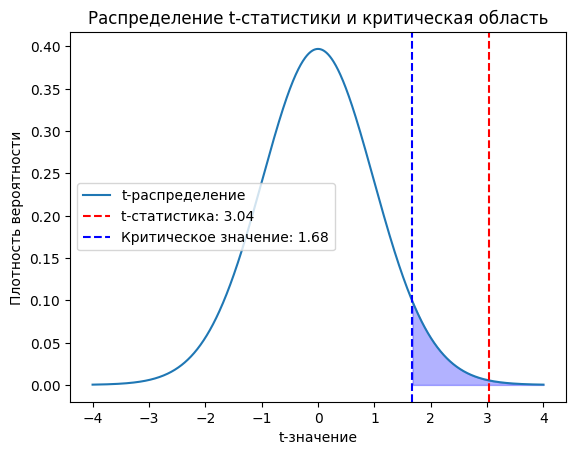

In [ ]:
# Первая группа - новый препарат
mean1 = 8
std1 = 2
n1 = 30

# Вторая группа - старый препарат
mean2 = 6
std2 = 3
n2 = 30

# Уровень значимости
alpha = 0.05

"""
H0: Среднее снижение давления равно (=) для обоих препаратов
H1: Среднее снижение препарата для первой группы больше (>), чем для второй группы
"""

# Считаем t-статистику
t_stat = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))

# Число степеней свободы по методу Уэлча
df = ((std1**2 / n1 + std2**2 / n2)**2) / (((std1**2 / n1)**2) / (n1 - 1) + ((std2**2 / n2)**2) / (n2 - 1))

# p-значение для одностороннего теста
p_value = 1 - t.cdf(t_stat, df)


print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы: {df:.2f}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и выбираем H1: новый препарат более эффективен, чем существующий")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: значимых различий в эффективности нет")

x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)

plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical = t.ppf(1 - alpha, df)
plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение: {t_critical:.2f}")
plt.fill_between(x, 0, y, where=(x >= t_critical), color="blue", alpha=0.3)
plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критическая область")
plt.show()

### Задача 6 (1 балл)

В университете внедрили новую методику преподавания математики и хотят оценить ее влияние на успеваемость студентов. Средний балл по математике в предыдущие годы был 75. После внедрения методики группа из 50 студентов получила средний балл 78 с стандартным отклонением 5. Проверить на уровне значимости 1%, улучшилась ли успеваемость студентов.

t-статистика: 4.24
Число степеней свободы: 49.00
p-значение: 0.0000
Отклоняем нулевую гипотезу H0: успеваемость студентов не изменилась, в пользу H1: успеваемость студентов улучшилась


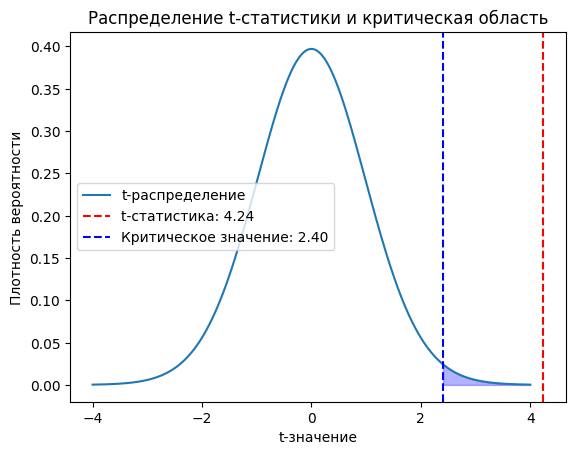

In [ ]:
"""
H0 : Успеваемость студентов не изменилась
H1 : Успеваемость студентов улучшилась

"""

mean = 75
mean_1 = 78
std = 5
n = 50
alpha = 0.01

t_stat = (mean_1 - mean) / (std / np.sqrt(n))
df = n - 1

p_value = 1 - t.cdf(t_stat, df)

print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы: {df:.2f}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0: успеваемость студентов не изменилась, в пользу H1: успеваемость студентов улучшилась")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: успеваемость студентов не изменилась")

x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)

plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical = t.ppf(1 - alpha, df)
plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение: {t_critical:.2f}")
plt.fill_between(x, 0, y, where=(x >= t_critical), color="blue", alpha=0.3)

plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критическая область")
plt.show()

### Задача 7 (1 балл)

Производитель утверждает, что его новый процессор работает на 20% быстрее предыдущей модели. Для проверки этого заявления были протестированы 40 новых и 40 старых процессоров. Новые процессоры в среднем выполняли задачу за 8 секунд с стандартным отклонением 1 секунда, старые — за 10 секунд с стандартным отклонением 1,5 секунды. Соответствует ли утверждение производителя действительности на уровне значимости 2%?

t-статистика: -7.02
Число степеней свободы: 67.95
p-значение: 0.0000
Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: новый процессор быстрее на 20% предыдущей модели


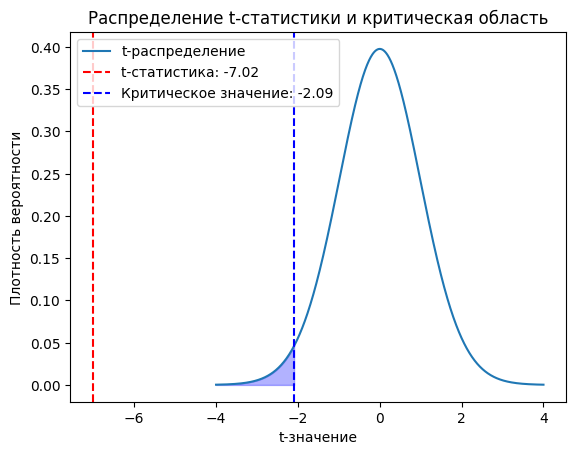

In [ ]:
n_new = n_old = 40
mean_new, mean_old = 8, 10
std_new, std_old = 1, 1.5
alpha = 0.02

"""
H0 : Среднее время выполнения новым процессором >= времени выполнения старым процессором
H1 : Среднее время выполнения новым процессором < времени выполнения старым процессором (новый процессор быстрее)
"""


t_stat = (mean_new - mean_old) / np.sqrt((std_new**2 / n_new) + (std_old**2 / n_old))
df = ((std_new**2 / n_new + std_old**2 / n_old)**2) / (
    ((std_new**2 / n_new)**2) / (n_new - 1) + ((std_old**2 / n_old)**2) / (n_old - 1)
)

# p-значение для одностороннего теста (левосторонний)
p_value = t.cdf(t_stat, df)


print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы: {df:.2f}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: новый процессор быстрее на 20% предыдущей модели")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: значимых различий в производительности нет")


x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)

plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical = t.ppf(alpha, df)
plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение: {t_critical:.2f}")
plt.fill_between(x, 0, y, where=(x <= t_critical), color="blue", alpha=0.3)
plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критическая область")
plt.show()

### Задача 8 (1 балл)

После введения новых экологических стандартов исследователь хочет определить, снизился ли уровень загрязнения воздуха в городе. До введения стандартов средняя концентрация вредных веществ составляла 50 мкг/м³. Через год после внедрения было проведено 36 измерений, и средняя концентрация составила 47 мкг/м³ со стандартным отклонением 4 мкг/м³. Можно ли на уровне значимости 5% считать, что уровень загрязнения воздуха снизился?

t-статистика: -4.50
Число степеней свободы: 35.00
p-значение: 0.0000
Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: средняя концентрация снизилась


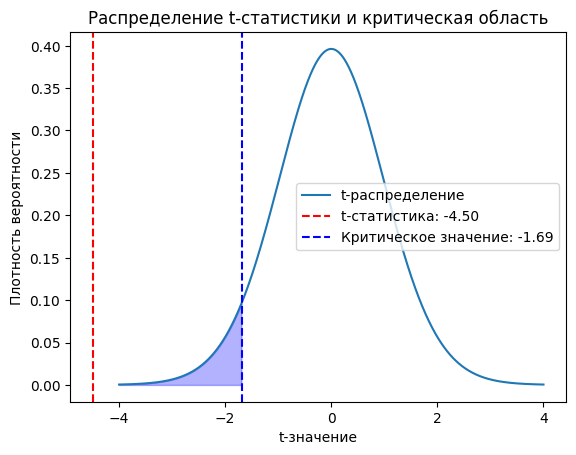

In [ ]:
"""
H0 : Средняя концентрация вредных веществ не изменилась
H1 : Средняя концентрация вредных веществ снизилась
"""

n = 36
mean_0 = 50
mean_1 = 47
std = 4
alpha = 0.05

t_stat = (mean_1 - mean_0) / (std / np.sqrt(n))
df = n - 1

p_value = t.cdf(t_stat, df)

print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы: {df:.2f}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: средняя концентрация снизилась")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: средняя концентрации не изменилась")

x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)

plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical = t.ppf(alpha, df)
plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение: {t_critical:.2f}")
plt.fill_between(x, 0, y, where=(x <= t_critical), color="blue", alpha=0.3)
plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критическая область")
plt.show()

### Задача 9 (1 балл)

В школе проводят эксперимент, чтобы выяснить, влияет ли дополнительное занятие по чтению на скорость чтения учеников. Учеников случайным образом разделили на две группы по 20 человек. Первая группа занималась по стандартной программе и показала среднюю скорость чтения 150 слов в минуту со стандартным отклонением 15 слов. Вторая группа посещала дополнительные занятия и показала среднюю скорость 160 слов в минуту со стандартным отклонением 10 слов. Является ли разница в скоростях статистически значимой на уровне значимости 5%?

t-статистика: -2.48
Число степеней свободы: 33.10
p-значение: 0.0184
Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: скорость чтения изменилась


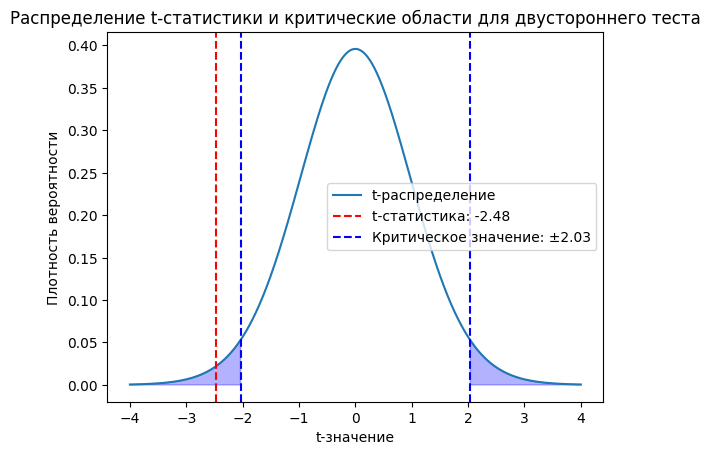

In [ ]:
n1 = n2 = 20
mean1, mean2 = 150, 160
std1, std2 = 15, 10
alpha = 0.05

"""
H0 : Средняя скорость чтения одинакова для обеих групп (μ1 = μ2)
H1 : Средняя скорость чтения различается для двух групп (μ1 ≠ μ2)
"""

t_stat = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))
df = ((std1**2 / n1 + std2**2 / n2)**2) / (((std1**2 / n1)**2) / (n1 - 1) + ((std2**2 / n2)**2) / (n2 - 1))

p_value = 2 * (1 - t.cdf(abs(t_stat), df))


print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы: {df:.2f}")
print(f"p-значение: {p_value:.4f}")


if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: скорость чтения изменилась")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: скорость чтения не изменилась")


x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)

plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")

t_critical = t.ppf(1 - alpha / 2, df)
plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение: ±{t_critical:.2f}")
plt.axvline(-t_critical, color='blue', linestyle='--')

plt.fill_between(x, 0, y, where=(x <= -t_critical) | (x >= t_critical), color="blue", alpha=0.3)

plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критические области для двустороннего теста")
plt.show()

### Задача 10 (1 балл)

Автомобильная компания хочет определить, влияет ли новый тип топлива на эффективность расхода топлива. В тесте участвовали 30 автомобилей, использующих обычное топливо, и 30 автомобилей на новом топливе. Средний расход для обычного топлива составил 8 литров на 100 км с стандартным отклонением 0,5 литра, для нового топлива — 7,5 литров на 100 км с стандартным отклонением 0,4 литра. Проверьте на уровне значимости 1%, улучшает ли новый тип топлива эффективность.

t-статистика: 4.28
Число степеней свободы (метод Уэлча): 55.33
p-значение: 1.0000
Нет оснований отклонить нулевую гипотезу H0: эффективность для нового топлива не больше


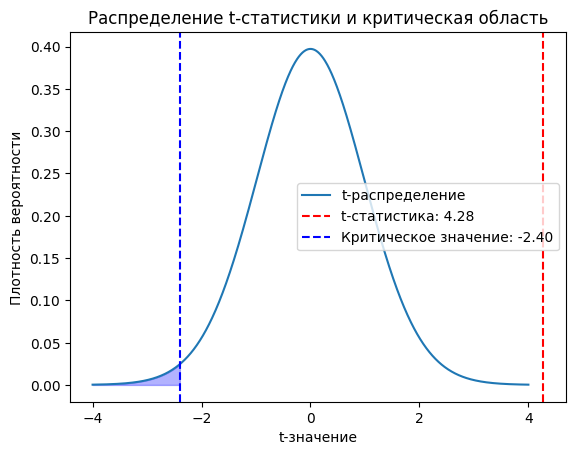

In [ ]:
n1 = n2 = 30
mean1, mean2 = 8, 7.5
std1, std2 = 0.5, 0.4
alpha = 0.01

"""
H0 : Средний расход одинаков для обоих видов топлива (>=)
H1 : Средний расход для нового топлива меньше (<)
"""

t_stat = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))
df = ((std1**2 / n1 + std2**2 / n2)**2) / (
    ((std1**2 / n1)**2) / (n1 - 1) + ((std2**2 / n2)**2) / (n2 - 1)
)

# Левосторонний тест - новое топливо должно расходовать меньше
p_value = t.cdf(t_stat, df)

print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы (метод Уэлча): {df:.2f}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: эффективность нового топлива больше")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: эффективность для нового топлива не больше")


x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)
plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical = t.ppf(alpha, df)
plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение: {t_critical:.2f}")
plt.fill_between(x, 0, y, where=(x <= t_critical), color="blue", alpha=0.3)
plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критическая область")
plt.show()

### Задача 11 (1 балл)

В исследовании психологии изучается влияние медитации на уровень стресса. Уровень стресса измеряется по шкале от 0 до 100. До начала программы медитации у группы из 25 участников средний уровень стресса был 70 с стандартным отклонением 8. После программы средний уровень снизился до 65 с стандартным отклонением 7. Является ли снижение уровня стресса статистически значимым на уровне значимости 5%?

t-статистика: 2.35
Число степеней свободы: 24
p-значение: 0.9864
Нет оснований отклонить нулевую гипотезу H0: уровень стресса не изменился


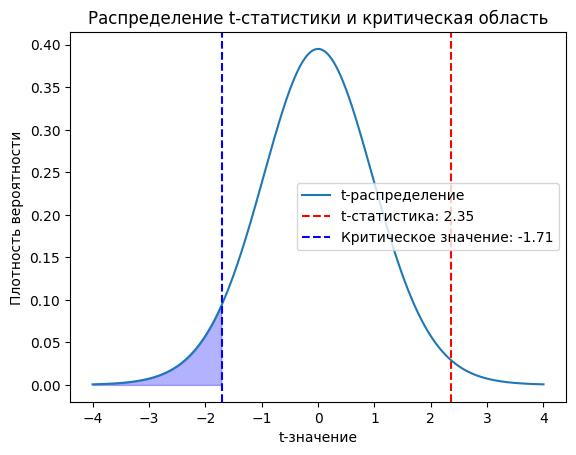

In [ ]:
n = 25
mean_before, mean_after = 70, 65
std_before, std_after = 8, 7
alpha = 0.05

"""
H0 : Средний уровень стресса не изменился
H1 : Средний уровень стресса снизился
"""

# Средняя разность
mean_diff = mean_before - mean_after
se_diff = np.sqrt((std_before**2 + std_after**2) / n)

# Вычисление t-статистики
t_stat = mean_diff / se_diff
df = n - 1

# Левосторонний тест
p_value = t.cdf(t_stat, df)

print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы: {df}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0: уровень стресса снизился")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: уровень стресса не изменился")

x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)

plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical = t.ppf(alpha, df)
plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение: {t_critical:.2f}")
plt.fill_between(x, 0, y, where=(x <= t_critical), color="blue", alpha=0.3)

plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критическая область")
plt.show()

### Задача 12 (1 балл)

Компания по производству напитков изменила рецепт своего продукта и хочет определить, повлияло ли это на предпочтения потребителей. В тестировании участвовали 200 человек, из которых 110 предпочли новый рецепт, а остальные остались нейтральны или выбрали старый. Можно ли на уровне значимости 1% утверждать, что большинство потребителей предпочитают новый рецепт?

z-статистика: 1.4142135623730963
z-критическое: 2.3263478740408408
Нет оснований отклонить нулевую гипотезу: потребители остались нейтральны или выбрали старый продукт


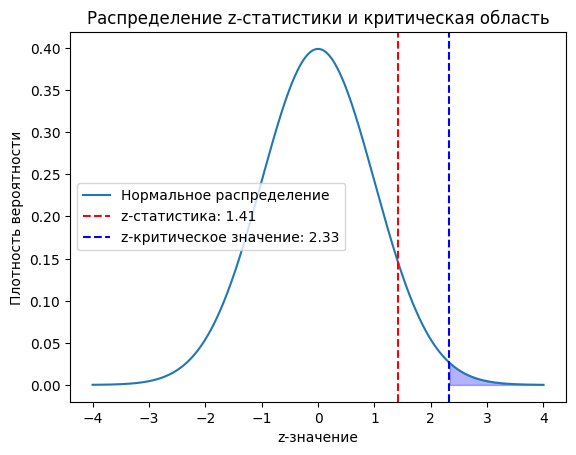

In [ ]:
n1 = 90
n2 = 110
alpha = 0.01
p_0 = 0.5

"""
H0 : Потребители не отдают предпочтение новому рецепту (p <= 0.5)
H1 : Большинство потребителей предпочитают новый рецепт (p > 0.5)
"""

p_hat = n2 / (n1 + n2)
# Стандартное отклонение для доли при условии, что p = 0.5
std_phat = np.sqrt((p_0 * (1 - p_0)) / (n1 + n2))
z_obs = (p_hat - p_0) / std_phat
z_critical = norm.ppf(1 - alpha)

print("z-статистика:", z_obs)
print("z-критическое:", z_critical)

if z_obs > z_critical:
    print("Отклоняем нулевую гипотезу H0 и принимаем альтернативную гипотезу: большинство потребителей предпочитает новый рецепт")
else:
    print("Нет оснований отклонить нулевую гипотезу: потребители остались нейтральны или выбрали старый продукт")


x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

plt.plot(x, y, label="Нормальное распределение")
plt.axvline(z_obs, color='red', linestyle='--', label=f"z-статистика: {z_obs:.2f}")
plt.axvline(z_critical, color='blue', linestyle='--', label=f"z-критическое значение: {z_critical:.2f}")
plt.fill_between(x, 0, y, where=(x >= z_critical), color="blue", alpha=0.3)

plt.legend()
plt.xlabel("z-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение z-статистики и критическая область")
plt.show()

### Задача 13 (1 балл)

В ходе эксперимента изучается влияние нового удобрения на рост растений. Группе из 15 растений добавляли новое удобрение, и средний рост составил 25 см с стандартным отклонением 3 см. Контрольная группа из 15 растений без удобрения показала средний рост 22 см с стандартным отклонением 2,5 см. Проверить на уровне значимости 5%, является ли разница в росте статистически значимой.

t-статистика: 2.98
Число степеней свободы (метод Уэлча): 27.12
p_value : 0.01
Отклоняем нулевую гипотезу H0 и принимаем альтернативную гипотезу: рост изменился


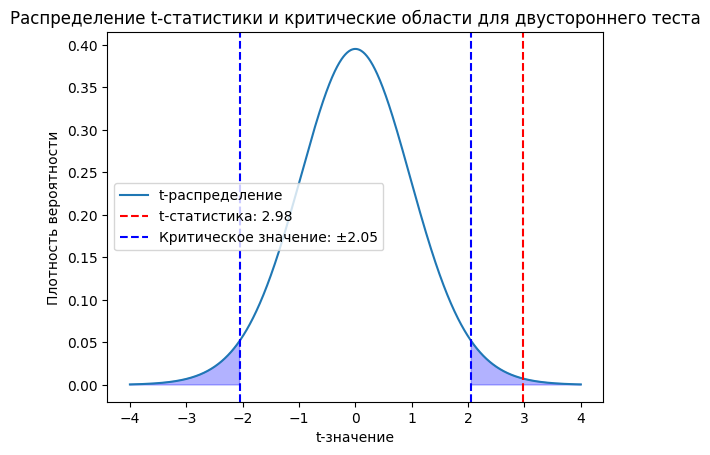

In [ ]:
n1 = n2 = 15
mean1, mean2 = 25, 22
std1, std2 = 3, 2.5
alpha = 0.05

"""
H0 : Средний рост одинаков для обоих групп (μ1 = μ2)
H1 : Средний рост для группы с удобрением больше, чем для контрольной группы (μ1 =/= μ2)
"""

t_stat = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))
df = ((std1**2 / n1 + std2**2 / n2)**2) / (((std1**2 / n1)**2) / (n1 - 1) + ((std2**2 / n2)**2) / (n2 - 1))
p_value = 2*(1 - t.cdf(abs(t_stat), df))

print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы (метод Уэлча): {df:.2f}")
print(f"p_value : {p_value:.2f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем альтернативную гипотезу: рост изменился")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: рост не изменился")

x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)

plt.plot(x, y, label="t-распределение")

plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical = t.ppf(1 - alpha / 2, df)
plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение: ±{t_critical:.2f}")
plt.axvline(-t_critical, color='blue', linestyle='--')

plt.fill_between(x, 0, y, where=(x <= -t_critical) | (x >= t_critical), color="blue", alpha=0.3)

plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критические области для двустороннего теста")
plt.show()

### Задача 14 (5 баллов за все пункты)

Пункт 1. Компания внедряет новую программу обучения сотрудников с целью повышения производительности труда. Ранее средняя производительность составляла 50 единиц в день при стандартном отклонении 8 единиц. После года действия программы случайно выбранная выборка из 80 сотрудников показала среднюю производительность 52 единицы. Считаем, что стандартное отклонение осталось неизменным. Можно ли на основе этих данных утверждать, что программа обучения действительно повысила производительность, или наблюдаемый результат мог возникнуть случайно? Сформулируйте нулевую и альтернативную гипотезы, определите тип теста (двусторонний, левосторонний или правосторонний) и проверьте нулевую гипотезу на уровнях значимости α = 1% и α = 5%.


---

Пункт 2. Решите пункт 1, если выборка состоит лишь из 5 сотрудников.


---

Пункт 3. Решите пункт 1 при условии, что стандартное отклонение увеличилось до 16 единиц.


---

Пункт 4. Решите пункт 1, если после внедрения программы средняя производительность составила 51 единицу.


---

Пункт 5. Решите пункт 1, если стандартное отклонение неизвестно, а выборка составила 25 сотрудников. Несмещённая оценка дисперсии выборки составила 64. Примите уровень значимости равным 5%.

In [ ]:
"""Дано"""

mean_old = 50
n = 80
mean_new = 53
std = 8
alpha = 0.01

z-статистика: -2.50
p-значение: 0.9938

Уровень значимости 1%
Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась

Уровень значимости 5%
Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась


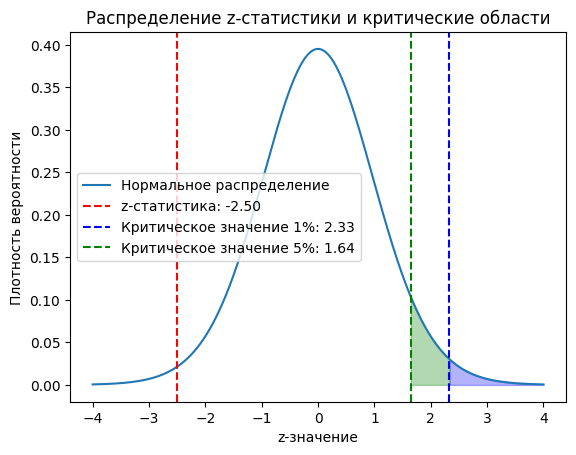

In [ ]:
"""
H0 : Средняя производительность не изменилась (=)
H1 : Средняя производительность увеличилась (>)
Тест: правосторонний
Считается, что известна генеральная совокупность и стандартное отклонение 8.
"""
alpha1 = 0.01
alpha2 = 0.05

# z-тест
se = std / np.sqrt(n)
z_stat = (mean_new - mean_old) / se
p_value = 1 - norm.cdf(z_stat)

print(f"z-статистика: {z_stat:.2f}")
print(f"p-значение: {p_value:.4f}")

print("\nУровень значимости 1%")
if p_value < alpha1:
    print("Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: средняя производительность увеличилась")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась")

print("\nУровень значимости 5%")
if p_value < alpha2:
    print("Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: средняя производительность увеличилась")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась")

plt.plot(x, y, label="Нормальное распределение")

plt.axvline(z_stat, color='red', linestyle='--', label=f"z-статистика: {z_stat:.2f}")
z_critical1 = norm.ppf(1 - alpha1)
z_critical2 = norm.ppf(1 - alpha2)

plt.axvline(z_critical1, color='blue', linestyle='--', label=f"Критическое значение 1%: {z_critical1:.2f}")
plt.axvline(z_critical2, color='green', linestyle='--', label=f"Критическое значение 5%: {z_critical2:.2f}")

plt.fill_between(x, 0, y, where=(x >= z_critical1), color="blue", alpha=0.3)
plt.fill_between(x, 0, y, where=(x >= z_critical2) & (x < z_critical1), color="green", alpha=0.3)

plt.legend()
plt.xlabel("z-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение z-статистики и критические области")
plt.show()

t-статистика: 0.17
Число степеней свободы: 4
p-значение: 0.4375

Уровень значимости 1%
Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась

Уровень значимости 5%
Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась


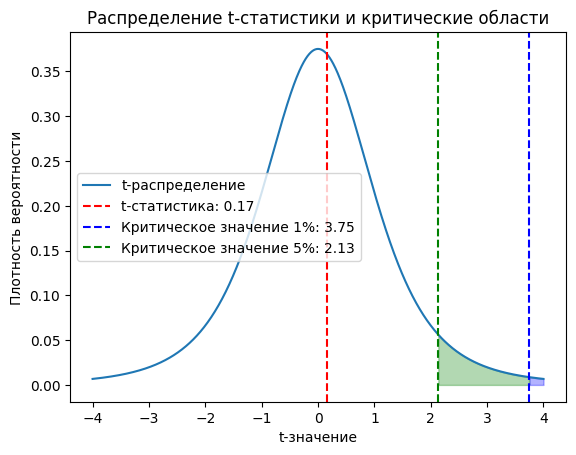

In [ ]:
"""
Пункт 2
"""
mean_old = 50
n = 5
mean_new = 53
std = 8
alpha = 0.01

# t-тест
t_stat = (mean_new - mean_old) / std / np.sqrt(n)
df = n - 1

p_value = 1 - t.cdf(t_stat, df)

print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы: {df}")
print(f"p-значение: {p_value:.4f}")

print("\nУровень значимости 1%")
if p_value < alpha1:
    print("Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: средняя производительность увеличилась")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась")

print("\nУровень значимости 5%")
if p_value < alpha2:
    print("Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: средняя производительность увеличилась")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась")

x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)

plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical1 = t.ppf(1 - alpha1, df)
t_critical2 = t.ppf(1 - alpha2, df)

plt.axvline(t_critical1, color='blue', linestyle='--', label=f"Критическое значение 1%: {t_critical1:.2f}")
plt.axvline(t_critical2, color='green', linestyle='--', label=f"Критическое значение 5%: {t_critical2:.2f}")

plt.fill_between(x, 0, y, where=(x >= t_critical1), color="blue", alpha=0.3)
plt.fill_between(x, 0, y, where=(x >= t_critical2) & (x < t_critical1), color="green", alpha=0.3)

plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критические области")
plt.show()

z-статистика: 1.68
p-значение: 0.0468

Уровень значимости 1%
Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась

Уровень значимости 5%
Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: средняя производительность увеличилась


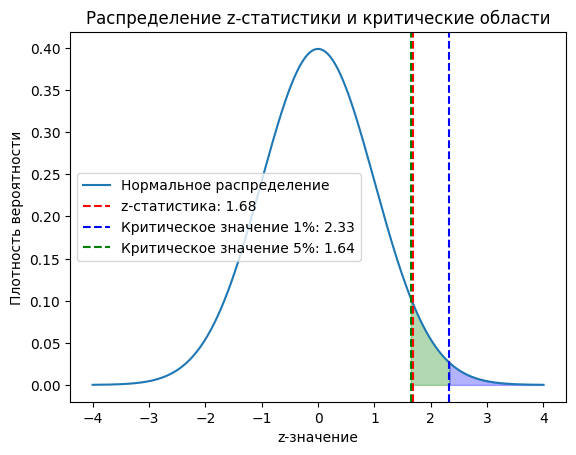

In [ ]:
"""
Пункт 3
"""

mean_old = 50
n = 80
mean_new = 53
std_old = 8
std_new = 16
alpha1 = 0.01
alpha2 = 0.05


se = std_new / np.sqrt(n)
z_stat = (mean_new - mean_old) / se
p_value = 1 - norm.cdf(z_stat)

print(f"z-статистика: {z_stat:.2f}")
print(f"p-значение: {p_value:.4f}")

print("\nУровень значимости 1%")
if p_value < alpha1:
    print("Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: средняя производительность увеличилась")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась")

print("\nУровень значимости 5%")
if p_value < alpha2:
    print("Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: средняя производительность увеличилась")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась")

x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)
plt.plot(x, y, label="Нормальное распределение")
plt.axvline(z_stat, color='red', linestyle='--', label=f"z-статистика: {z_stat:.2f}")
z_critical1 = norm.ppf(1 - alpha1)
z_critical2 = norm.ppf(1 - alpha2)

plt.axvline(z_critical1, color='blue', linestyle='--', label=f"Критическое значение 1%: {z_critical1:.2f}")
plt.axvline(z_critical2, color='green', linestyle='--', label=f"Критическое значение 5%: {z_critical2:.2f}")

plt.fill_between(x, 0, y, where=(x >= z_critical1), color="blue", alpha=0.3)
plt.fill_between(x, 0, y, where=(x >= z_critical2) & (x < z_critical1), color="green", alpha=0.3)

plt.legend()
plt.xlabel("z-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение z-статистики и критические области")
plt.show()

z-статистика: 1.12
p-значение: 0.1318

Уровень значимости 1%
Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась

Уровень значимости 5%
Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась


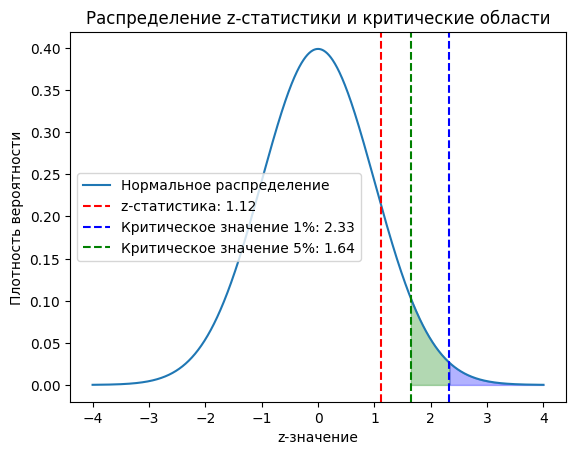

In [ ]:
"""
Пункт 4
"""
mean_old = 50
n = 80
mean_new = 51
std = 8

alpha1 = 0.01
alpha2 = 0.05

se = std / np.sqrt(n)
z_stat = (mean_new - mean_old) / se
p_value = 1 - norm.cdf(z_stat)

print(f"z-статистика: {z_stat:.2f}")
print(f"p-значение: {p_value:.4f}")

print("\nУровень значимости 1%")
if p_value < alpha1:
    print("Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: средняя производительность увеличилась")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась")

print("\nУровень значимости 5%")
if p_value < alpha2:
    print("Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: средняя производительность увеличилась")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась")

plt.plot(x, y, label="Нормальное распределение")
plt.axvline(z_stat, color='red', linestyle='--', label=f"z-статистика: {z_stat:.2f}")

z_critical1 = norm.ppf(1 - alpha1)
z_critical2 = norm.ppf(1 - alpha2)

plt.axvline(z_critical1, color='blue', linestyle='--', label=f"Критическое значение 1%: {z_critical1:.2f}")
plt.axvline(z_critical2, color='green', linestyle='--', label=f"Критическое значение 5%: {z_critical2:.2f}")

plt.fill_between(x, 0, y, where=(x >= z_critical1), color="blue", alpha=0.3)
plt.fill_between(x, 0, y, where=(x >= z_critical2) & (x < z_critical1), color="green", alpha=0.3)

plt.legend()
plt.xlabel("z-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение z-статистики и критические области")
plt.show()

t-статистика: 1.88
Число степеней свободы: 24
p-значение: 0.0365

Уровень значимости 5%
Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: средняя производительность увеличилась


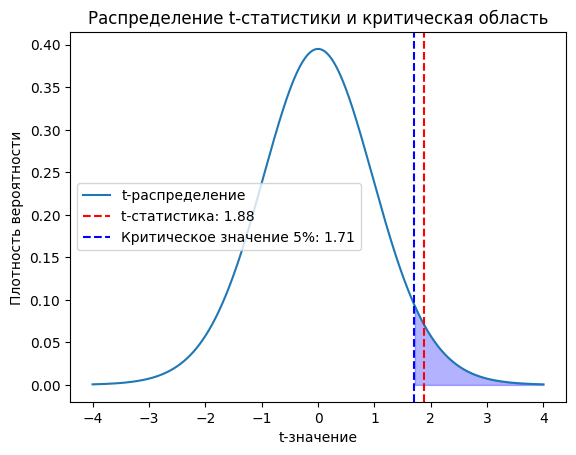

In [ ]:
"""
Пункт 5
"""
mean_old = 50
n = 25
mean_new = 53
var_sample = 64
std_sample = np.sqrt(var_sample)
alpha = 0.05

# t-тест
se = std_sample / np.sqrt(n)
t_stat = (mean_new - mean_old) / se

df = n - 1
p_value = 1 - t.cdf(t_stat, df)

print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы: {df}")
print(f"p-значение: {p_value:.4f}")

print("\nУровень значимости 5%")
if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем новую гипотезу: средняя производительность увеличилась")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: средняя производительность не изменилась")


x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)

plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical = t.ppf(1 - alpha, df)

plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение 5%: {t_critical:.2f}")
plt.fill_between(x, 0, y, where=(x >= t_critical), color="blue", alpha=0.3)

plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критическая область")
plt.show()

### Задача 15 (3 балла за все пункты)

Задача 1. Компания оценивает эффективность нового программного обеспечения для повышения производительности сотрудников. Перед установкой ПО среднее время выполнения определённой задачи у 60 сотрудников составляло 100 минут с известным стандартным отклонением 12 минут. После установки нового ПО среднее время выполнения той же задачи снизилось до 95 минут. Считаем, что стандартное отклонение осталось неизменным. Можно ли на уровне значимости α = 5% утверждать, что новое ПО действительно снижает время выполнения задачи? Сформулируйте нулевую и альтернативную гипотезы, определите тип теста и проверьте нулевую гипотезу.


---

Задача 2. Решите задачу 1, если стандартное отклонение после установки нового ПО неизвестно, а выборка составляет 25 сотрудников. По полученным данным несмещённая оценка дисперсии после установки ПО составляет 144 минуты².


---

Задача 3. Компания сравнивает эффективность двух независимых групп сотрудников: первая группа из 50 человек использует старое ПО, вторая группа из 50 человек — новое ПО. Среднее время выполнения задачи в первой группе составляет 100 минут со стандартным отклонением 12 минут, во второй группе — 95 минут со стандартным отклонением 12 минут. Можно ли на уровне значимости α = 5% утверждать, что новое ПО снижает время выполнения задачи по сравнению со старым?


---

Задача 4. Для оценки влияния обучающего курса на навыки сотрудников компания измеряет время выполнения задачи у 30 сотрудников до и после прохождения курса. Среднее время до обучения составляет 80 минут, после обучения — 75 минут. Известно, что стандартное отклонение разностей времени (до и после) составляет 5 минут. Можно ли на уровне значимости α = 1% утверждать, что обучение улучшило навыки сотрудников? Сформулируйте нулевую и альтернативную гипотезы и выберите подходящий статистический тест.


---

Задача 5. Решите задачу 4, если стандартное отклонение разностей времени неизвестно, а несмещённая оценка дисперсии разностей составляет 25 минут². Примите уровень значимости равным 1%.

t-статистика: 3.23
Число степеней свободы: 59
p-значение: 0.9990
Нет оснований отклонить нулевую гипотезу H0: среднее время не изменилось.


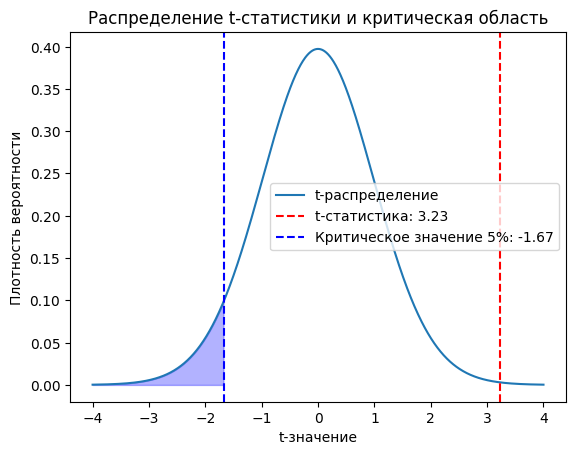

In [ ]:
n = 60
mean_before = 100
mean_after = 95
std = 12
alpha = 0.05

"""
H0 : Среднее время выполнения больше или равно (>=)
H1 : Среднее время выполнения снизилось (<)
"""

mean_diff = mean_before - mean_after
se_diff = std / np.sqrt(n)
t_stat = mean_diff / se_diff
df = n - 1

# Левосторонний тест
p_value = t.cdf(t_stat, df)

print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы: {df}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем альтернативную гипотезу: среднее время снизилось.")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: среднее время не изменилось.")

x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)
plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical = t.ppf(alpha, df)
plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение 5%: {t_critical:.2f}")
plt.fill_between(x, 0, y, where=(x <= t_critical), color="blue", alpha=0.3)
plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критическая область")
plt.show()


Задача 2. Решите задачу 1, если стандартное отклонение после установки нового ПО неизвестно, а выборка составляет 25 сотрудников. По полученным данным несмещённая оценка дисперсии после установки ПО составляет 144 минуты².

t-статистика: 1.47
Число степеней свободы: 48.00
p-значение: 0.9264
Нет оснований отклонить нулевую гипотезу H0: среднее время не изменилось.


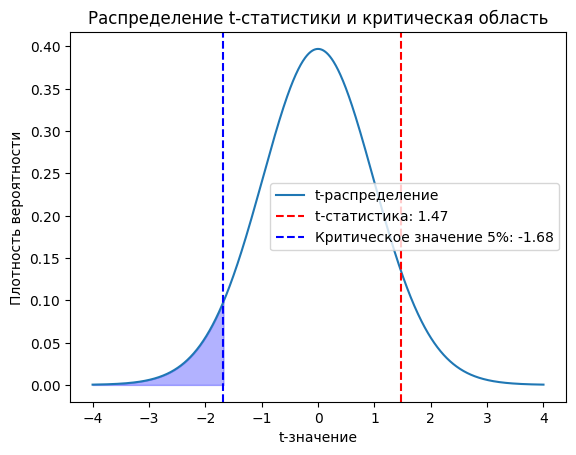

In [ ]:
"""
Задача 2
"""

n1 = 25
mean1 = 100
std1 = 12

n2 = 25
mean2 = 95
var2 = 144
std2 = np.sqrt(var2)

alpha = 0.05

mean_diff = mean1 - mean2
t_stat = mean_diff / np.sqrt((std1**2 / n1) + (std2**2 / n2))
df = ((std1**2 / n1 + std2**2 / n2)**2) / (((std1**2 / n1)**2 / (n1 - 1)) + ((std2**2 / n2)**2 / (n2 - 1)))

# p-значение для левостороннего теста
p_value = t.cdf(t_stat, df)

print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы: {df:.2f}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем альтернативную гипотезу: среднее время снизилось.")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: среднее время не изменилось.")


x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)
plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical = t.ppf(alpha, df)
plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение 5%: {t_critical:.2f}")
plt.fill_between(x, 0, y, where=(x <= t_critical), color="blue", alpha=0.3)
plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критическая область")
plt.show()

Задача 3. Компания сравнивает эффективность двух независимых групп сотрудников: первая группа из 50 человек использует старое ПО, вторая группа из 50 человек — новое ПО. Среднее время выполнения задачи в первой группе составляет 100 минут со стандартным отклонением 12 минут, во второй группе — 95 минут со стандартным отклонением 12 минут. Можно ли на уровне значимости α = 5% утверждать, что новое ПО снижает время выполнения задачи по сравнению со старым?

t-статистика: 2.08
Число степеней свободы: 98
p-значение: 0.0199
Отклоняем нулевую гипотезу H0 и принимаем альтернативную гипотезу: новое ПО снижает время выполнения задачи.


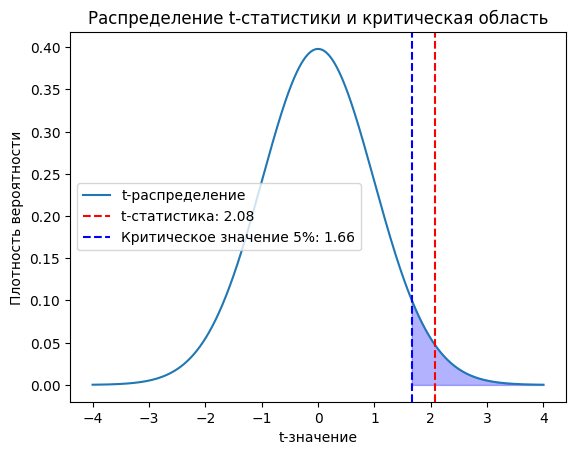

In [ ]:
"""
Задача 3
"""
from scipy.stats import t
import numpy as np

n1 = 50
mean1 = 100
std1 = 12

n2 = 50
mean2 = 95
std2 = 12

alpha = 0.05

mean_diff = mean1 - mean2
pooled_variance = ((std1**2 / n1) + (std2**2 / n2))
se_diff = np.sqrt(pooled_variance)

# t-статистика
t_stat = mean_diff / se_diff

# Число степеней свободы
df = n1 + n2 - 2

# Правосторонний
p_value = 1 - t.cdf(t_stat, df)

print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы: {df}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем альтернативную гипотезу: новое ПО снижает время выполнения задачи.")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: время выполнения задачи не снизилось.")

x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)
plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical = t.ppf(1 - alpha, df)
plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение 5%: {t_critical:.2f}")
plt.fill_between(x, 0, y, where=(x >= t_critical), color="blue", alpha=0.3)
plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критическая область")
plt.show()

Задача 4. Для оценки влияния обучающего курса на навыки сотрудников компания измеряет время выполнения задачи у 30 сотрудников до и после прохождения курса. Среднее время до обучения составляет 80 минут, после обучения — 75 минут. Известно, что стандартное отклонение разностей времени (до и после) составляет 5 минут. Можно ли на уровне значимости α = 1% утверждать, что обучение улучшило навыки сотрудников? Сформулируйте нулевую и альтернативную гипотезы и выберите подходящий статистический тест.

t-статистика: 5.48
Число степеней свободы: 29
p-значение: 1.0000
Нет оснований отклонить нулевую гипотезу H0: время выполнения не изменилось.


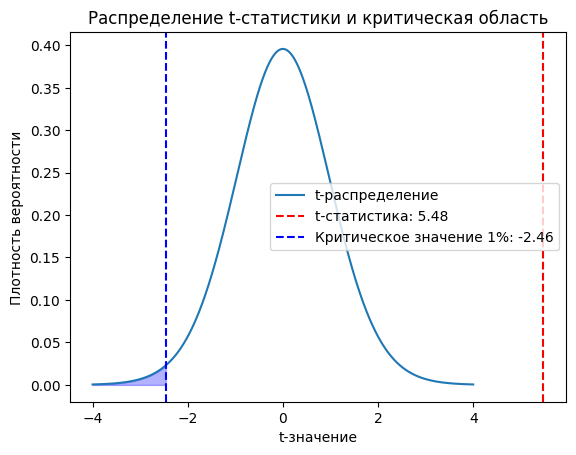

In [ ]:
"""
Задача 4
"""

"""
H0 : Среднее время выполнения равно (>=)
H1 : Среднее время выполнения снизилось (<)
"""

n = 30
mean_before = 80
mean_after = 75
std_diff = 5
alpha = 0.01

t_stat = (mean_before - mean_after) / (std_diff / np.sqrt(n))
df = n - 1
p_value = t.cdf(t_stat, df)

print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы: {df}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем альтернативную гипотезу: время выполнения снизилось.")
else:
  print("Нет оснований отклонить нулевую гипотезу H0: время выполнения не изменилось.")


x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)
plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical = t.ppf(alpha, df)
plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение 1%: {t_critical:.2f}")
plt.fill_between(x, 0, y, where=(x <= t_critical), color="blue", alpha=0.3)
plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критическая область")
plt.show()


Задача 4. Для оценки влияния обучающего курса на навыки сотрудников компания измеряет время выполнения задачи у 30 сотрудников до и после прохождения курса. Среднее время до обучения составляет 80 минут, после обучения — 75 минут. Известно, что стандартное отклонение разностей времени (до и после) составляет 5 минут. Можно ли на уровне значимости α = 1% утверждать, что обучение улучшило навыки сотрудников? Сформулируйте нулевую и альтернативную гипотезы и выберите подходящий статистический тест.


---

Задача 5. Решите задачу 4, если стандартное отклонение разностей времени неизвестно, а несмещённая оценка дисперсии разностей составляет 25 минут². Примите уровень значимости равным 1%.

t-статистика: 5.48
Число степеней свободы: 29
p-значение: 1.0000
Нет оснований отклонить нулевую гипотезу H0: время выполнения не изменилось.


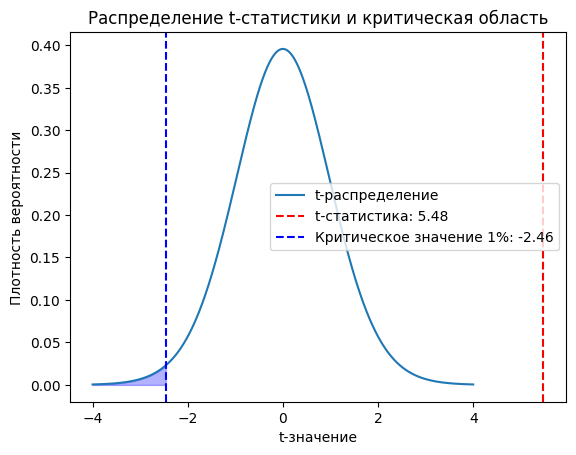

In [ ]:
n = 30
mean_before = 80
mean_after = 75
variance_diff = 25
std_diff = np.sqrt(variance_diff)
alpha = 0.01

se_diff = std_diff / np.sqrt(n)
t_stat = (mean_before - mean_after )/ se_diff
df = n - 1

p_value = t.cdf(t_stat, df)

print(f"t-статистика: {t_stat:.2f}")
print(f"Число степеней свободы: {df}")
print(f"p-значение: {p_value:.4f}")

if p_value < alpha:
    print("Отклоняем нулевую гипотезу H0 и принимаем альтернативную гипотезу: время выполнения снизилось.")
else:
    print("Нет оснований отклонить нулевую гипотезу H0: время выполнения не изменилось.")

x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)
plt.plot(x, y, label="t-распределение")
plt.axvline(t_stat, color='red', linestyle='--', label=f"t-статистика: {t_stat:.2f}")
t_critical = t.ppf(alpha, df)
plt.axvline(t_critical, color='blue', linestyle='--', label=f"Критическое значение 1%: {t_critical:.2f}")
plt.fill_between(x, 0, y, where=(x <= t_critical), color="blue", alpha=0.3)
plt.legend()
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение t-статистики и критическая область")
plt.show()


### Задача 16 (4 балла за все пункты)

Монетку подбросили n=150 раз. Из них выпало Y орлов. Вероятность выпадения орла равна p.

(a) При каких значениях Y вы отвергнете нулевую гипотезу H0:p=1/2 против односторонней альтернативы p>1/2 на уровне значимости α=0.05?

(b) Предположим, что на самом деле H0​ не выполняется, а выполняется H1​, и вероятность выпадения орла равна p=1/2+δ, где δ=1/10. При этом мы не знаем точное значение p, но действуем согласно нашему критерию. С какой вероятностью мы при этом отвергнем гипотезу H0​? Какова вероятность совершить ошибку второго рода (не отвергнуть H0​, когда H1​ истинна)?

(c) Решите ту же задачу для δ=1/100.

(d) Решите ту же задачу для δ=1/100 и n=1000.

z-критическое: 1.6448536269514722
Кол-во бросков (неокругленное) : 85.10414518898062
Минимальное возможное кол-во выпадений Орлов (округленное) : 86.0
z-статистика: 1.796292478040998
Отклоняем нулевую гипотезу H0 и принимаем альтернативную гипотезу


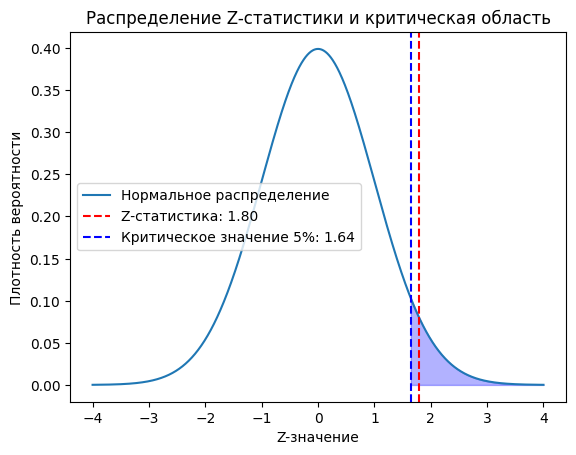

In [ ]:
"""
Задача (а)
"""

"""
H0 : p = 0.5
H1 : p > 0.5
"""
n = 150
alpha = 0.05
p_0 = 0.5


std_phat = np.sqrt((p_0 * (1 - p_0)) / n)

z_critical = norm.ppf(1 - alpha)
print("z-критическое:", z_critical)

# Ищем z_obs, так чтобы z_obs > z_critical, миниамальное возможное 1.65

z_obs = 1.65
n2 = (z_obs + (p_0 / std_phat)) * n * std_phat
print(f"Кол-во бросков (неокругленное) : {n2}")
n2_round = np.ceil(n2)
print(f"Минимальное возможное кол-во выпадений Орлов (округленное) : {n2_round}")

# Проверка
z_obs = (n2_round / n - p_0) / std_phat
print("z-статистика:", z_obs)

if z_obs > z_critical:
    print("Отклоняем нулевую гипотезу H0 и принимаем альтернативную гипотезу")
else:
    print("Нет оснований отклонить нулевую гипотезу")

x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

plt.plot(x, y, label="Нормальное распределение")
plt.axvline(z_obs, color='red', linestyle='--', label=f"Z-статистика: {z_obs:.2f}")
plt.axvline(z_critical, color='blue', linestyle='--', label=f"Критическое значение 5%: {z_critical:.2f}")
plt.fill_between(x, 0, y, where=(x >= z_critical), color="blue", alpha=0.3)
plt.legend()
plt.xlabel("Z-значение")
plt.ylabel("Плотность вероятности")
plt.title("Распределение Z-статистики и критическая область")
plt.show()

Монетку подбросили n=150 раз. Из них выпало Y орлов. Вероятность выпадения орла равна p.

(a) При каких значениях Y вы отвергнете нулевую гипотезу H0:p=1/2 против односторонней альтернативы p>1/2 на уровне значимости α=0.05?

(b) Предположим, что на самом деле H0​ не выполняется, а выполняется H1​, и вероятность выпадения орла равна p=1/2+δ, где δ=1/10. При этом мы не знаем точное значение p, но действуем согласно нашему критерию. С какой вероятностью мы при этом отвергнем гипотезу H0​? Какова вероятность совершить ошибку второго рода (не отвергнуть H0​, когда H1​ истинна)?

In [ ]:
n = 150
alpha = 0.05
p = 0.5
p_alt = 1/2 + 1/10
delta = p_alt - p

z_critical = norm.ppf(1 - alpha)

std_phat = np.sqrt((p * (1 - p)) / n)
n2 = (z_critical + (p / std_phat)) * n * std_phat
n2_rounded = np.ceil(n2)

print(f"Минимальное значение Y для отклонения H0: {n2_rounded}")

mean_alt = n * p_alt
std_p_alt = np.sqrt(n * p_alt * (1 - p_alt))

# Мощность теста (вероятность отвергнуть H0, когда H1 истинна)
z_power = (n2_rounded - mean_alt) / std_p_alt
power = 1 - norm.cdf(z_power)


# Вероятность ошибки второго рода
beta = 1 - power

print(f"Мощность теста (1 - β): {power:.4f}")
print(f"Вероятность ошибки второго рода (β): {beta:.4f}")

Минимальное значение Y для отклонения H0: 86.0
Мощность теста (1 - β): 0.7475
Вероятность ошибки второго рода (β): 0.2525


(c) Решите ту же задачу для δ=1/100.

In [ ]:
n = 150
alpha = 0.05
p = 0.5
p_alt = 1/2 + 1/100
delta = p_alt - p

z_critical = norm.ppf(1 - alpha)

std_phat = np.sqrt((p * (1 - p)) / n)
n2 = (z_critical + (p / std_phat)) * n * std_phat
n2_rounded = np.ceil(n2)

print(f"Минимальное значение Y для отклонения H0: {n2_rounded}")

mean_alt = n * p_alt
std_p_alt = np.sqrt(n * p_alt * (1 - p_alt))

# Мощность теста (вероятность отвергнуть H0, когда H1 истинна)
z_power = (n2_rounded - mean_alt) / std_p_alt
power = 1 - norm.cdf(z_power)


# Вероятность ошибки второго рода
beta = 1 - power

print(f"Мощность теста (1 - β): {power:.4f}")
print(f"Вероятность ошибки второго рода (β): {beta:.4f}")

Минимальное значение Y для отклонения H0: 86.0
Мощность теста (1 - β): 0.0604
Вероятность ошибки второго рода (β): 0.9396


(d) Решите ту же задачу для δ=1/100 и n=1000.

In [ ]:
from scipy.stats import norm
import numpy as np

n = 1000
alpha = 0.05
p = 0.5
p_alt = 0.5 + 1/100
delta = p_alt - p

z_critical = norm.ppf(1 - alpha)
std_phat = np.sqrt((p * (1 - p)) / n)

n2 = n * (p + z_critical * std_phat)
n2_rounded = np.ceil(n2)

print(f"Минимальное значение Y для отклонения H0: {n2_rounded}")

mean_alt = n * p_alt
std_p_alt = np.sqrt(n * p_alt * (1 - p_alt))

z_power = (n2_rounded - mean_alt) / std_p_alt
power = 1 - norm.cdf(z_power)

beta = 1 - power

print(f"Мощность теста (1 - β): {power:.4f}")
print(f"Вероятность ошибки второго рода (β): {beta:.4f}")


Минимальное значение Y для отклонения H0: 527.0
Мощность теста (1 - β): 0.1411
Вероятность ошибки второго рода (β): 0.8589
